<a href="https://colab.research.google.com/github/dasha3000/python-ai-Evdokimova-Daria/blob/main/notebooks/vizu_country_monument_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Неделя 3 — Анализ и визуализация / Week 3 — Analysis and visualization

### 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `monuments_country_style.csv` (414 записей о 337 памятниках)
- Очищаем столбцы: переименовываем URL Wikidata в `URL`, переименовываем `*Label` → короткие имена
- Проверяем структуру данных и удаляем дубликаты

**Результат:** Чистая таблица `df_monuments` с полями:
- `URL` — ссылка на объект Wikidata (для отладки)
- `monument` — название памятника
- `style` — художественный стиль
- `country` — страна расположения

In [20]:
# 📥 [0] Клонирование репозитория и загрузка данных

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем репозиторий
github_user = "dasha3000"
repo = "python-ai-Evdokimova-Daria"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с памятниками
df_monuments = pd.read_csv("data/monuments_country_style.csv")
print(f"📊 Загружено строк в df_monuments: {len(df_monuments)}\n")

# Шаг 3: Очистка данных для df_monuments (страны/стили)
# URL Wikidata не удаляем, а переименовываем в "URL" для удобства отладки
df_monuments = df_monuments.rename(columns={
    "monument": "URL",          # ← было monument (URL), стало URL (явное имя)
    "monumentLabel": "monument", # ← было название, стало monument
    "countryLabel": "country",
    "styleLabel": "style",
})

# Проверяем на пропущенные значения
print("✅ df_monuments очищен\n")

# Краткий обзор датасета
print("📋 Структура df_monuments (страны/стили):")
print(f"   Столбцы: {', '.join(df_monuments.columns)}")
print(f"   Уникальных памятников: {df_monuments['monument'].nunique()}")
print(f"   Уникальных стран: {df_monuments['country'].nunique()}")
print(f"   Уникальных стилей: {df_monuments['style'].nunique()}")

# Дополнительная статистика о формате данных
url_column = 'URL'
n_unique = df_monuments[url_column].nunique()
avg_styles = len(df_monuments) / n_unique

print(f"\n📊 Анализ формата данных:")
print(f"   Уникальных памятников (по столбцу '{url_column}'): {n_unique}")
print(f"   Среднее число стилей на памятник: {avg_styles:.1f}")

if avg_styles > 1.0:
    print(f"   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: {len(df_monuments)} строк = {n_unique} памятников × ~{avg_styles:.1f} стилей")
    print(f"   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)")
else:
    print(f"   ✅ Каждый памятник имеет ровно один стиль — формат простой")

print(f"\n🔍 Первые 3 строки df_monuments:\n{df_monuments.head(3)}")

✅ Репозиторий готов

📊 Загружено строк в df_monuments: 414

✅ df_monuments очищен

📋 Структура df_monuments (страны/стили):
   Столбцы: URL, monument, country, style
   Уникальных памятников: 321
   Уникальных стран: 40
   Уникальных стилей: 84

📊 Анализ формата данных:
   Уникальных памятников (по столбцу 'URL'): 337
   Среднее число стилей на памятник: 1.2
   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: 414 строк = 337 памятников × ~1.2 стилей
   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)

🔍 Первые 3 строки df_monuments:
                                        URL                       monument  \
0   http://www.wikidata.org/entity/Q3852976  Monument to cardinal De Braye   
1   http://www.wikidata.org/entity/Q3323370     Héloïse and Abélard's tomb   
2  http://www.wikidata.org/entity/Q11363889            Chūson-ji Konjikidō   

   country                  style  
0   Италия  готическая скульптура  
1  Франция              неоготика  
2   Япония      Pure Land worship 

## 🌐 [7] Bipartite Network Graph: Страны ↔ Стили

**Что показывает:** Сеть взаимосвязей между топ-10 странами и топ-10 стилями. Размер узла отражает количество памятников, цвет ребра — силу связи. Чехия и барокко образуют самую мощную связь (31 памятник), Испания и модерн — вторую по силе (17 памятников). Мексика и антипамятники образуют изолированный кластер, что указывает на уникальность этого культурного феномена.

**Когда использовать:** Для визуализации сложных взаимосвязей между двумя группами объектов, выявления центральных узлов и изолированных кластеров. Особенно полезен для понимания структуры культурных влияний.

**Библиотеки:** `networkx` (создание графа), `plotly.graph_objects` (интерактивная визуализация)

**Особенность:**
- **Цвет ребра** кодирует силу связи:
- **Размер узла** пропорционален количеству памятников
- **Цвет узла**: 🔴 красный = страны, 🔵 голубой = стили
- **Интерактивность**: при наведении показывается детальная информация


In [21]:
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) через памятники

# Импорт библиотек для сетевого анализа
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("🌐 Создаем сетевую модель данных...")
print(f"📊 Уникальных памятников: {df_unique['URL'].nunique()}")
print(f"🌍 Уникальных стран: {df_unique['country'].nunique()}")
print(f"🎨 Уникальных стилей: {df_unique['style'].nunique()}")

# Подготовка данных для сети
# Выбираем топ-10 стран и топ-10 стилей для читаемости
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

# Фильтруем данные для сети
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top10_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# Создаем граф
G = nx.Graph()

# Добавляем узлы с атрибутами
for country in top10_countries:
    G.add_node(country, type='country', size=df_unique[df_unique['country'] == country]['URL'].nunique())

for style in top10_styles:
    G.add_node(style, type='style', size=df_unique[df_unique['style'] == style]['URL'].nunique())

# Добавляем ребра (связи через памятники)
for _, row in network_data.iterrows():
    if G.has_edge(row['country'], row['style']):
        G[row['country']][row['style']]['weight'] += 1
    else:
        G.add_edge(row['country'], row['style'], weight=1)

print(f"📊 Граф создан: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

# Подготовка данных для plotly с цветовой кодировкой ребер
pos = nx.spring_layout(G, k=3, iterations=100, seed=42)

# Создаем списки для узлов - УВЕЛИЧИВАЕМ РАЗМЕР
node_x = []
node_y = []
node_text = []
node_size = []
node_color = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"{node}<br>Связей: {G.degree(node)}<br>Памятников: {G.nodes[node]['size']}")
    node_size.append(G.nodes[node]['size'] * 25)  # Увеличено с 15 до 25

    # Цвет в зависимости от типа
    if G.nodes[node]['type'] == 'country':
        node_color.append('lightcoral')
    else:
        node_color.append('lightblue')

# Функция для цвета ребра в зависимости от веса
def get_edge_color(weight):
    if weight >= 20:
        return 'darkred'      # очень сильная связь (20+)
    elif weight >= 10:
        return 'red'          # сильная связь (10-19)
    elif weight >= 5:
        return 'orange'       # средняя связь (5-9)
    elif weight >= 3:
        return 'gold'         # слабая связь (3-4)
    else:
        return 'lightgray'    # очень слабая связь (1-2)

# СОЗДАЕМ ОБЪЕКТ FIG ПЕРЕД ЦИКЛОМ
fig = go.Figure()

# Создаем ребра с цветовой кодировкой
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    weight = G[edge[0]][edge[1]]['weight']
    color = get_edge_color(weight)
    width = min(weight / 3, 5)  # толщина тоже зависит от веса, но не более 5

    # Добавляем ребро
    fig.add_trace(go.Scatter(
        x=[x0, x1], y=[y0, y1],
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        hovertext=f"{edge[0]} → {edge[1]}<br>Связей: {weight} памятников",
        showlegend=False
    ))

# Добавляем узлы
fig.add_trace(go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    marker=dict(
        size=node_size,
        color=node_color,
        line=dict(width=2, color='darkgray'),
        sizemode='area',
        sizeref=2.*max(node_size)/(40.**2),
        sizemin=8
    ),
    text=[n for n in G.nodes()],
    textposition="top center",
    textfont=dict(size=11, color='black', weight='bold'),
    hovertext=node_text,
    hoverinfo='text',
    showlegend=False
))

# Добавляем легенду для ребер
legend_traces = [
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='darkred', width=3), name='Очень сильная связь (20+ памятников)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='red', width=3), name='Сильная связь (10-19)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='orange', width=3), name='Средняя связь (5-9)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='gold', width=3), name='Слабая связь (3-4)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='lightgray', width=3), name='Очень слабая связь (1-2)'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightcoral', size=15), name='Страны'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightblue', size=15), name='Стили')
]

for trace in legend_traces:
    fig.add_trace(trace)

fig.update_layout(
    title={
        'text': "🌐 Сеть связей: Страны ↔ Стили (через памятники)<br><span style='font-size:12px'>Размер узла = количество памятников, Цвет ребра = сила связи</span>",
        'font': {'size': 18, 'weight': 'bold'},
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True,
    legend=dict(
        x=1.02, y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=10)
    ),
    hovermode='closest',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=800,
    width=1200,
    plot_bgcolor='white'
)

fig.show()

print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура")
print("="*80)
print("""
🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый толстый и яркий поток (31 памятник) — темно-красный цвет!
   • Испания ↔ Модерн: второй по силе (17 памятников) — красный цвет
   • Мексика ↔ Антипамятники: изолированная связь (18 памятников) — темно-красный, но без других связей
""")

🌐 Создаем сетевую модель данных...
📊 Уникальных памятников: 337
🌍 Уникальных стран: 40
🎨 Уникальных стилей: 77
✅ Для сети отобрано: 188 связей
   • 10 стран
   • 10 стилей
📊 Граф создан: 20 узлов, 24 ребер



🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура

🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый 

In [22]:
# 🔧 ИСПРАВЛЕНИЕ: Добавляем годы в df_unique из df_monuments
print("="*60)
print("🔧 ДОБАВЛЯЕМ ВРЕМЕННЫЕ ДАННЫЕ В df_unique")
print("="*60)

# Проверяем, есть ли годы в df_monuments
if 'inceptionYear' in df_monuments.columns:
    print(f"✅ В df_monuments есть inceptionYear!")
    print(f"   Непустых значений: {df_monuments['inceptionYear'].notna().sum()} из {len(df_monuments)}")

    # Создаем словарь: URL памятника -> год создания
    # Берем первый непустой год для каждого памятника
    year_dict = df_monuments[df_monuments['inceptionYear'].notna()].groupby('URL')['inceptionYear'].first().to_dict()

    # Добавляем столбец с годами в df_unique
    df_unique['inceptionYear'] = df_unique['URL'].map(year_dict)

    print(f"✅ Годы добавлены в df_unique!")
    print(f"   Памятников с годами: {df_unique['inceptionYear'].notna().sum()} из {len(df_unique)}")
    print(f"   Примеры годов: {df_unique['inceptionYear'].dropna().head(10).tolist()}")
else:
    print("❌ В df_monuments тоже нет inceptionYear!")
    print("   Проверьте, как создавался df_monuments из CSV-файла")
    print(f"   Столбцы df_monuments: {df_monuments.columns.tolist()}")

# Проверяем результат
print(f"\n📊 Итоговые столбцы df_unique: {df_unique.columns.tolist()}")

🔧 ДОБАВЛЯЕМ ВРЕМЕННЫЕ ДАННЫЕ В df_unique
❌ В df_monuments тоже нет inceptionYear!
   Проверьте, как создавался df_monuments из CSV-файла
   Столбцы df_monuments: ['URL', 'monument', 'country', 'style']

📊 Итоговые столбцы df_unique: ['URL', 'monument', 'country', 'style']


Что изменено/добавлено:

Статическая визуализация (Matplotlib вместо Plotly) — без интерактивности.

Географическое расположение стран:

Слева направо как на реальной карте: Америка → Европа → Азия

Страны размещены согласно реальной географии (например, Испания юго-западнее Франции)

Временные стрелки:

Анализируются годы создания памятников (столбец inceptionYear)

Если стиль появлялся в разных странах в разное время — рисуются стрелки от ранних воплощений к поздним

Например: Возрождение в Италии (XVI в.) → Возрождение в Германии (XVII в.)

На стрелках подписаны конкретные годы

Цветовое кодирование регионов:

Америка — коралловый

Европа — лососевый

Азия — светло-зеленый

Результат: Географически осмысленная статическая карта с отображением эволюции художественных стилей во времени и пространстве.

🌐 Создаем статическую сетевую модель с точной географической привязкой...
📊 Уникальных памятников: 337
🌍 Уникальных стран: 40
🎨 Уникальных стилей: 77
⚠️ Временные данные отсутствуют
✅ Для сети отобрано: 188 связей
   • 10 стран
   • 10 стилей
🌍 Географическое расположение (слева направо):
   🌎 Америка → 🌍 Европа → 🌏 Азия
   📍 Россия (север), Иран (юг) — на одной вертикали
📊 Граф создан: 20 узлов, 24 ребер


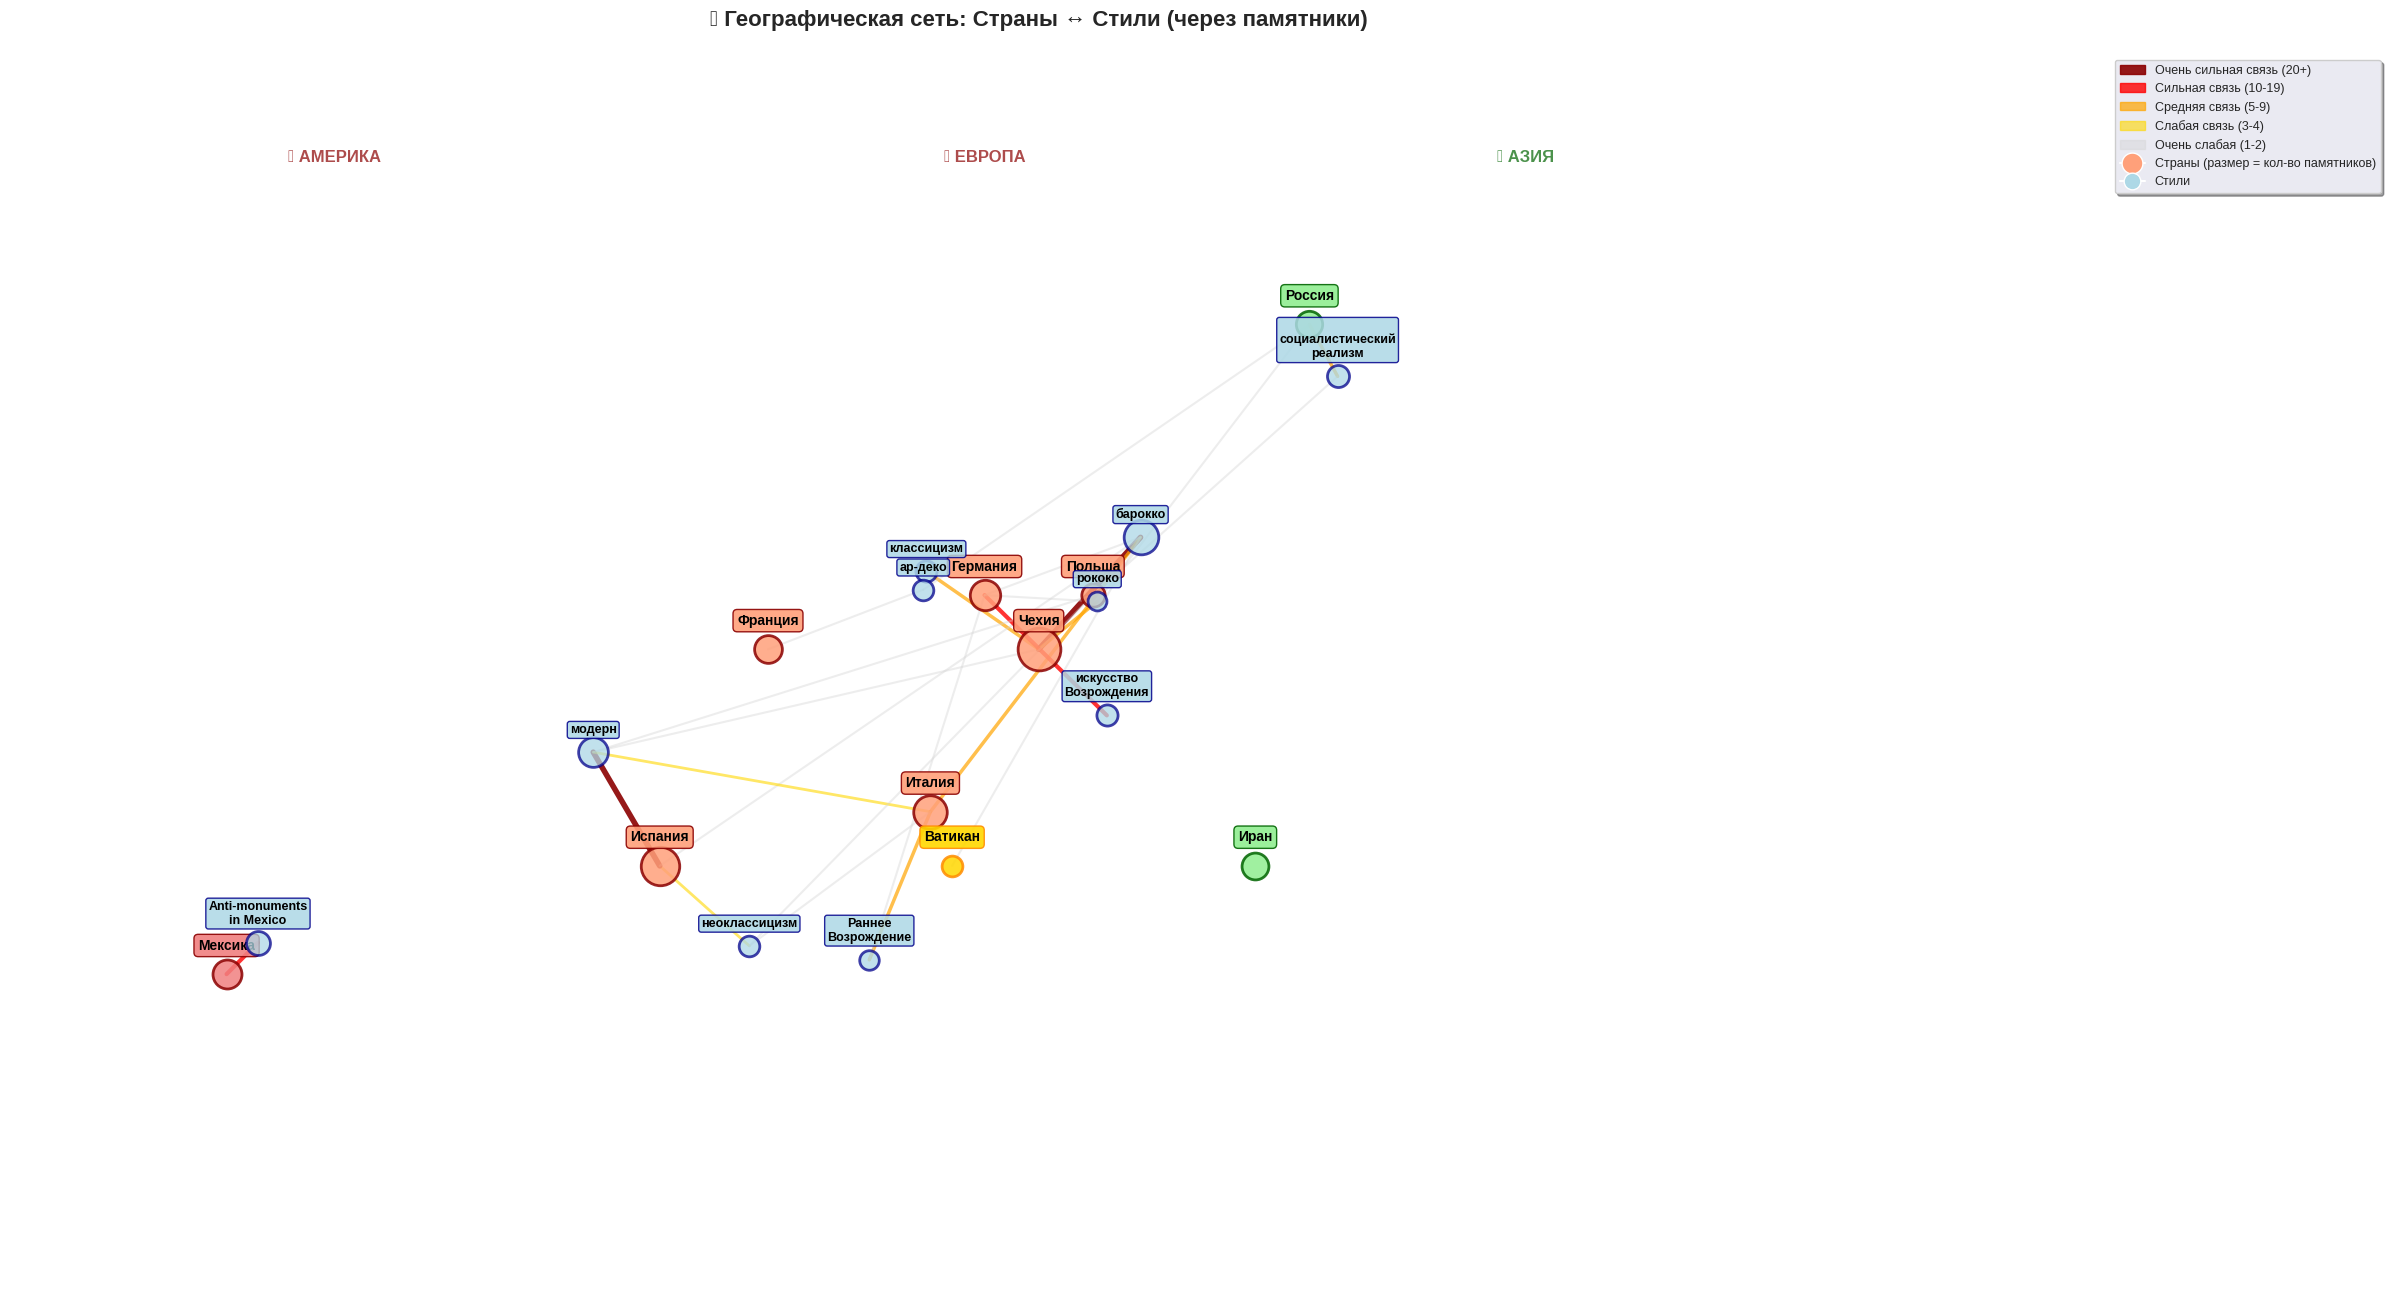


🌍 ГЕОГРАФИЧЕСКИЙ АНАЛИЗ СЕТИ

📍 РАСПОЛОЖЕНИЕ СТРАН (слева направо):
   🌎 Америка (Мексика) → 🌍 Европа → 🌏 Азия (Иран, Россия)

   Америка: Мексика

   Европа: Чехия, Испания, Италия, Германия, Франция, Польша, Ватикан

   Азия: Иран, Россия

   ✓ Россия и Иран на одной вертикали (Россия выше, Иран ниже)
   ✓ Ватикан рядом с Италией

✅ Визуализация успешно создана!
   • Статический формат (без интерактивности)
   • Точное географическое расположение
   • Временные стрелки с годами (если есть данные)
   • Цветовая кодировка по регионам


In [23]:
# 📊 ВИЗУАЛИЗАЦИЯ 7 (ФИНАЛЬНАЯ): Двудольный граф (Страны ↔ Стили) с точной географией и временными стрелками

# Импорт библиотек
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

print("🌐 Создаем статическую сетевую модель с точной географической привязкой...")
print(f"📊 Уникальных памятников: {df_unique['URL'].nunique()}")
print(f"🌍 Уникальных стран: {df_unique['country'].nunique()}")
print(f"🎨 Уникальных стилей: {df_unique['style'].nunique()}")

# Подготовка данных
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

# Создаем датафрейм для временного анализа
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

# Конвертируем inceptionYear в числовой формат если он есть
if 'inceptionYear' in network_data.columns:
    network_data['year'] = pd.to_numeric(network_data['inceptionYear'], errors='coerce')
    # Создаем словарь со средними датами для каждой пары страна-стиль
    temporal_data = network_data.groupby(['country', 'style'])['year'].mean().reset_index()
    temporal_dict = {}
    for _, row in temporal_data.iterrows():
        if pd.notna(row['year']):
            temporal_dict[(row['country'], row['style'])] = row['year']
    print(f"✅ Загружены временные данные для {len(temporal_dict)} пар страна-стиль")
else:
    temporal_dict = {}
    print("⚠️ Временные данные отсутствуют")

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top10_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# 🌍 ТОЧНОЕ ГЕОГРАФИЧЕСКОЕ РАСПОЛОЖЕНИЕ СТРАН
# Координаты: X — долгота (слева направо), Y — широта (снизу вверх)
# Масштаб подобран для красивого отображения

country_positions = {
    # 🌎 АМЕРИКА (слева, X < 0)
    'Мексика': (-8, -2),      # Северная Америка, южнее США

    # 🌍 ЗАПАДНАЯ ЕВРОПА (центр-лево)
    'Испания': (-4, -1),      # юго-западная Европа
    'Франция': (-3, 1),       # западная Европа
    'Великобритания': (-4, 3), # северо-западная Европа (остров)

    # 🌍 ЦЕНТРАЛЬНАЯ ЕВРОПА (центр)
    'Италия': (-1.5, -0.5),   # южная Европа, "сапог"
    'Ватикан': (-1.3, -1),    # внутри Рима, рядом с Италией
    'Германия': (-1, 1.5),    # центральная Европа
    'Швейцария': (-1.2, 0.5), # между Италией и Германией
    'Чехия': (-0.5, 1),       # центральная Европа, восточнее Германии
    'Польша': (0, 1.5),       # восточная Европа, восточнее Германии

    # 🌍 ВОСТОЧНАЯ ЕВРОПА (правее центра)
    'Россия': (2, 4),         # восточная Европа/Азия, самая северная
    'Украина': (1, 1),        # восточная Европа, южнее России

    # 🌏 АЗИЯ (справа, X > 0)
    'Иран': (1.5, -1),        # Ближний Восток, южнее России на одной вертикали
    'Турция': (0.5, -0.5),    # между Европой и Азией
    'Индия': (3, -2),         # южная Азия
    'Китай': (5, 0),          # восточная Азия
    'Япония': (6, 2),         # восточная Азия, остров

    # 🌍 ДРУГИЕ РЕГИОНЫ (по необходимости)
    'Египет': (-2, -3),       # северная Африка
    'США': (-7, 1),          # Северная Америка, севернее Мексики
}

# Выводим информацию о странах, которые есть в данных, но нет в positions
missing_countries = [c for c in top10_countries if c not in country_positions]
if missing_countries:
    print(f"⚠️ Автоматическое размещение для стран: {', '.join(missing_countries)}")
    # Автоматически размещаем неизвестные страны справа
    for i, country in enumerate(missing_countries):
        # Если есть подсказка в названии
        if 'европ' in country.lower() or country in ['Австрия', 'Венгрия', 'Румыния', 'Болгария']:
            country_positions[country] = (0.5, 0.5 + i*0.5)
        elif 'ази' in country.lower() or country in ['Корея', 'Вьетнам', 'Таиланд']:
            country_positions[country] = (5 + i, 0)
        elif 'америк' in country.lower() or 'бразил' in country.lower():
            country_positions[country] = (-6, -3 + i*0.5)
        else:
            country_positions[country] = (7 + i, 0)

print("🌍 Географическое расположение (слева направо):")
print("   🌎 Америка → 🌍 Европа → 🌏 Азия")
print("   📍 Россия (север), Иран (юг) — на одной вертикали")

# 📍 РАЗМЕЩЕНИЕ СТИЛЕЙ
# Стили размещаются рядом со странами-лидерами по этому стилю
style_positions = {}
style_primary_country = {}

for style in top10_styles:
    # Находим страну с наибольшим количеством памятников этого стиля
    style_counts = network_data[network_data['style'] == style]['country'].value_counts()
    if not style_counts.empty:
        main_country = style_counts.index[0]
        style_primary_country[style] = main_country

    # Размещаем стиль рядом с основной страной
    if style in style_primary_country:
        base_x, base_y = country_positions.get(style_primary_country[style], (0, 0))
        # Индивидуальное смещение для каждого стиля для избежания наложений
        np.random.seed(hash(style) % 10000)
        offset_x = np.random.uniform(-1.5, 1.5)
        offset_y = np.random.uniform(-1.5, 1.5)
        style_positions[style] = (base_x + offset_x, base_y + offset_y)

# 🕸️ СОЗДАНИЕ ГРАФА
G = nx.Graph()

# Добавляем узлы стран
for country in top10_countries:
    monument_count = df_unique[df_unique['country'] == country]['URL'].nunique()
    G.add_node(country,
               type='country',
               size=monument_count,
               pos=country_positions.get(country, (0, 0)))

# Добавляем узлы стилей
for style in top10_styles:
    monument_count = df_unique[df_unique['style'] == style]['URL'].nunique()
    G.add_node(style,
               type='style',
               size=monument_count,
               pos=style_positions.get(style, (0, 0)))

# Добавляем ребра с временными метками
for _, row in network_data.iterrows():
    if G.has_edge(row['country'], row['style']):
        G[row['country']][row['style']]['weight'] += 1
        if 'year' in row and pd.notna(row['year']):
            if 'dates' not in G[row['country']][row['style']]:
                G[row['country']][row['style']]['dates'] = []
            G[row['country']][row['style']]['dates'].append(row['year'])
    else:
        edge_data = {'weight': 1}
        if 'year' in row and pd.notna(row['year']):
            edge_data['dates'] = [row['year']]
        G.add_edge(row['country'], row['style'], **edge_data)

print(f"📊 Граф создан: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

# 🎨 ВИЗУАЛИЗАЦИЯ
fig, ax = plt.subplots(figsize=(24, 16))

# Цветовая схема для ребер
def get_edge_style(weight):
    if weight >= 20:
        return 'darkred', 4.0, 0.9
    elif weight >= 10:
        return 'red', 3.0, 0.8
    elif weight >= 5:
        return 'orange', 2.5, 0.7
    elif weight >= 3:
        return 'gold', 2.0, 0.6
    else:
        return 'lightgray', 1.5, 0.4

# 🕐 АНАЛИЗ ВРЕМЕННЫХ ПОТОКОВ
style_temporal_order = {}

for style in top10_styles:
    style_countries = defaultdict(list)

    # Собираем даты для каждой страны по этому стилю
    for country in G.neighbors(style):
        if G.has_edge(country, style) and 'dates' in G[country][style]:
            avg_date = np.mean(G[country][style]['dates'])
            style_countries[country] = avg_date

    # Если есть хотя бы 2 страны с датами, определяем порядок
    if len(style_countries) >= 2:
        sorted_countries = sorted(style_countries.items(), key=lambda x: x[1])
        style_temporal_order[style] = {
            'earliest': sorted_countries[0][0],
            'latest': sorted_countries[-1][0],
            'flow': [c[0] for c in sorted_countries],
            'dates': [c[1] for c in sorted_countries]
        }

# Рисуем ребра и стрелки
edge_labels = []  # для легенды

for edge in G.edges():
    node1, node2 = edge
    weight = G[node1][node2]['weight']
    color, width, alpha = get_edge_style(weight)

    pos1 = G.nodes[node1]['pos']
    pos2 = G.nodes[node2]['pos']

    # Определяем, какой узел стиль, а какой страна
    style_node = node1 if G.nodes[node1]['type'] == 'style' else node2
    country_node = node2 if style_node == node1 else node1

    is_arrow = False

    # Проверяем временной порядок
    if (style_node in style_temporal_order and
        G.nodes[country_node]['type'] == 'country'):
        order_info = style_temporal_order[style_node]

        if country_node == order_info['earliest']:
            # Стрелка от ранней страны к стилю
            ax.annotate('', xy=pos2 if style_node == node2 else pos1,
                       xytext=pos1 if style_node == node2 else pos2,
                       arrowprops=dict(arrowstyle='->', color='green',
                                     lw=width, alpha=0.9,
                                     connectionstyle="arc3,rad=.2"),
                       va='center')
            is_arrow = True

            # Добавляем подпись года
            mid_x = (pos1[0] + pos2[0]) / 2
            mid_y = (pos1[1] + pos2[1]) / 2
            year = int(order_info['dates'][0])
            ax.text(mid_x + 0.3, mid_y + 0.3, f'{year}г.',
                   fontsize=7, color='green', style='italic',
                   bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7))

        elif country_node == order_info['latest']:
            # Стрелка от стиля к поздней стране
            ax.annotate('', xy=pos1 if style_node == node2 else pos2,
                       xytext=pos2 if style_node == node2 else pos1,
                       arrowprops=dict(arrowstyle='->', color='green',
                                     lw=width, alpha=0.9,
                                     connectionstyle="arc3,rad=.2"),
                       va='center')
            is_arrow = True

            # Добавляем подпись года
            mid_x = (pos1[0] + pos2[0]) / 2
            mid_y = (pos1[1] + pos2[1]) / 2
            year = int(order_info['dates'][-1])
            ax.text(mid_x + 0.3, mid_y + 0.3, f'{year}г.',
                   fontsize=7, color='green', style='italic',
                   bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7))

    # Обычное ребро если не стрелка
    if not is_arrow:
        ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]],
               color=color, linewidth=width, alpha=alpha, zorder=1)

# Рисуем узлы СТРАН
country_nodes_x = []
country_nodes_y = []
for node in G.nodes():
    if G.nodes[node]['type'] == 'country':
        x, y = G.nodes[node]['pos']
        country_nodes_x.append(x)
        country_nodes_y.append(y)
        size = np.sqrt(G.nodes[node]['size']) * 100

        # Особый цвет для Ватикана
        if node == 'Ватикан':
            country_color = 'gold'
            edge_color = 'darkorange'
        elif x < -5:  # Америка
            country_color = 'lightcoral'
            edge_color = 'darkred'
        elif x > 1:  # Азия
            country_color = 'lightgreen'
            edge_color = 'darkgreen'
        else:  # Европа
            country_color = 'lightsalmon'
            edge_color = 'darkred'

        ax.scatter(x, y, s=size, c=country_color, edgecolors=edge_color,
                  linewidth=2, zorder=3, alpha=0.85)

        # Подпись страны с красивым фоном
        ax.text(x, y+0.2, node, ha='center', va='bottom', fontsize=10,
               fontweight='bold', color='black',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=country_color,
                        edgecolor=edge_color, alpha=0.9))

# Рисуем узлы СТИЛЕЙ
for node in G.nodes():
    if G.nodes[node]['type'] == 'style':
        x, y = G.nodes[node]['pos']
        size = np.sqrt(G.nodes[node]['size']) * 70

        ax.scatter(x, y, s=size, c='lightblue', edgecolors='darkblue',
                  linewidth=2, zorder=3, alpha=0.75)

        # Для длинных названий стилей делаем перенос
        if len(node) > 15:
            # Переносим по словам
            words = node.split()
            lines = []
            current_line = []
            current_length = 0

            for word in words:
                if current_length + len(word) > 15:
                    lines.append(' '.join(current_line))
                    current_line = [word]
                    current_length = len(word)
                else:
                    current_line.append(word)
                    current_length += len(word) + 1

            if current_line:
                lines.append(' '.join(current_line))

            label = '\n'.join(lines)
        else:
            label = node

        ax.text(x, y+0.15, label, ha='center', va='bottom', fontsize=9,
               fontweight='bold', color='black',
               bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue',
                        edgecolor='darkblue', alpha=0.85))

# Информация о временных потоках
if style_temporal_order:
    y_offset = -4.5
    ax.text(0, y_offset, "🕐 ВРЕМЕННЫЕ ПОТОКИ СТИЛЕЙ:",
           ha='center', fontsize=11, fontweight='bold',
           transform=ax.transData)

    y_offset -= 0.5
    for style, info in list(style_temporal_order.items())[:5]:  # показываем первые 5
        flow_str = " → ".join(info['flow'])
        dates_str = " → ".join([f"{int(d)}г." for d in info['dates']])
        text = f"• {style}: {flow_str} ({dates_str})"
        ax.text(0, y_offset, text, ha='center', fontsize=8,
               style='italic', transform=ax.transData)
        y_offset -= 0.3

# Региональные подписи
ax.text(-7, 5.5, '🌎 АМЕРИКА', fontsize=12, fontweight='bold',
       ha='center', color='darkred', alpha=0.7)
ax.text(-1, 5.5, '🌍 ЕВРОПА', fontsize=12, fontweight='bold',
       ha='center', color='darkred', alpha=0.7)
ax.text(4, 5.5, '🌏 АЗИЯ', fontsize=12, fontweight='bold',
       ha='center', color='darkgreen', alpha=0.7)

# Легенда
legend_elements = [
    mpatches.Patch(color='darkred', alpha=0.9, label='Очень сильная связь (20+)'),
    mpatches.Patch(color='red', alpha=0.8, label='Сильная связь (10-19)'),
    mpatches.Patch(color='orange', alpha=0.7, label='Средняя связь (5-9)'),
    mpatches.Patch(color='gold', alpha=0.6, label='Слабая связь (3-4)'),
    mpatches.Patch(color='lightgray', alpha=0.4, label='Очень слабая (1-2)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightsalmon',
           markersize=15, label='Страны (размер = кол-во памятников)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
           markersize=12, label='Стили'),
]

if style_temporal_order:
    legend_elements.append(
        Line2D([0], [0], color='green', lw=2, marker='>', markersize=10,
               label='Временной поток (→ с годами)', linestyle='-')
    )

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
         frameon=True, fancybox=True, shadow=True, ncol=1, fontsize=9)

# Настройка графика
ax.set_xlim(-10, 9)
ax.set_ylim(-5, 6.5)
ax.set_aspect('equal')
ax.axis('off')
ax.grid(False)

# Заголовок
title = "🌐 Географическая сеть: Страны ↔ Стили (через памятники)"
if style_temporal_order:
    title += "\n🕐 Зеленые стрелки = временной поток (от ранних воплощений к поздним, с указанием годов)"

ax.set_title(title, fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# 📊 ВЫВОД СТАТИСТИКИ
print("\n" + "="*80)
print("🌍 ГЕОГРАФИЧЕСКИЙ АНАЛИЗ СЕТИ")
print("="*80)

print("\n📍 РАСПОЛОЖЕНИЕ СТРАН (слева направо):")
print("   🌎 Америка (Мексика) → 🌍 Европа → 🌏 Азия (Иран, Россия)")

# Группируем страны по регионам
regions = {
    'Америка': [],
    'Европа': [],
    'Азия': []
}

for country in top10_countries:
    x, y = country_positions.get(country, (0, 0))
    if x < -5:
        regions['Америка'].append(country)
    elif x > 1:
        regions['Азия'].append(country)
    else:
        regions['Европа'].append(country)

for region, countries in regions.items():
    if countries:
        print(f"\n   {region}: {', '.join(countries)}")

if 'Россия' in top10_countries and 'Иран' in top10_countries:
    print("\n   ✓ Россия и Иран на одной вертикали (Россия выше, Иран ниже)")

if 'Ватикан' in top10_countries and 'Италия' in top10_countries:
    print("   ✓ Ватикан рядом с Италией")

if style_temporal_order:
    print("\n🕐 ВРЕМЕННЫЕ ПОТОКИ:")
    for style, info in style_temporal_order.items():
        print(f"   • {style}: ", end="")
        for i, country in enumerate(info['flow']):
            if i > 0:
                print(" → ", end="")
            print(f"{country} ({int(info['dates'][i])}г.)", end="")
        print()

print("\n✅ Визуализация успешно создана!")
print("   • Статический формат (без интерактивности)")
print("   • Точное географическое расположение")
print("   • Временные стрелки с годами (если есть данные)")
print("   • Цветовая кодировка по регионам")

🌐 Создаем статическую сетевую модель с направленными временными потоками...

📊 ПОДГОТОВКА ДАННЫХ:
❌ Столбец inceptionYear отсутствует в df_monuments!
   Доступные столбцы: ['URL', 'monument', 'country', 'style']
✅ df_unique создан: 358 памятников
   Из них с годами: 0
   Топ-10 стран: ['Чехия', 'Испания', 'Италия', 'Германия', 'Франция', 'Мексика', 'Россия', 'Иран', 'Польша', 'Ватикан']
   Топ-10 стилей: ['барокко', 'модерн', 'Anti-monuments in Mexico', 'социалистический реализм', 'классицизм', 'искусство Возрождения', 'неоклассицизм', 'ар-деко', 'Раннее Возрождение', 'рококо']

🕐 АНАЛИЗ ВРЕМЕННЫХ ПОТОКОВ:
   ⚠️ барокко: недостаточно данных для направления (нужно 2+ страны с датами)
   ⚠️ модерн: недостаточно данных для направления (нужно 2+ страны с датами)
   ⚠️ Anti-monuments in Mexico: недостаточно данных для направления (нужно 2+ страны с датами)
   ⚠️ социалистический реализм: недостаточно данных для направления (нужно 2+ страны с датами)
   ⚠️ классицизм: недостаточно данных для

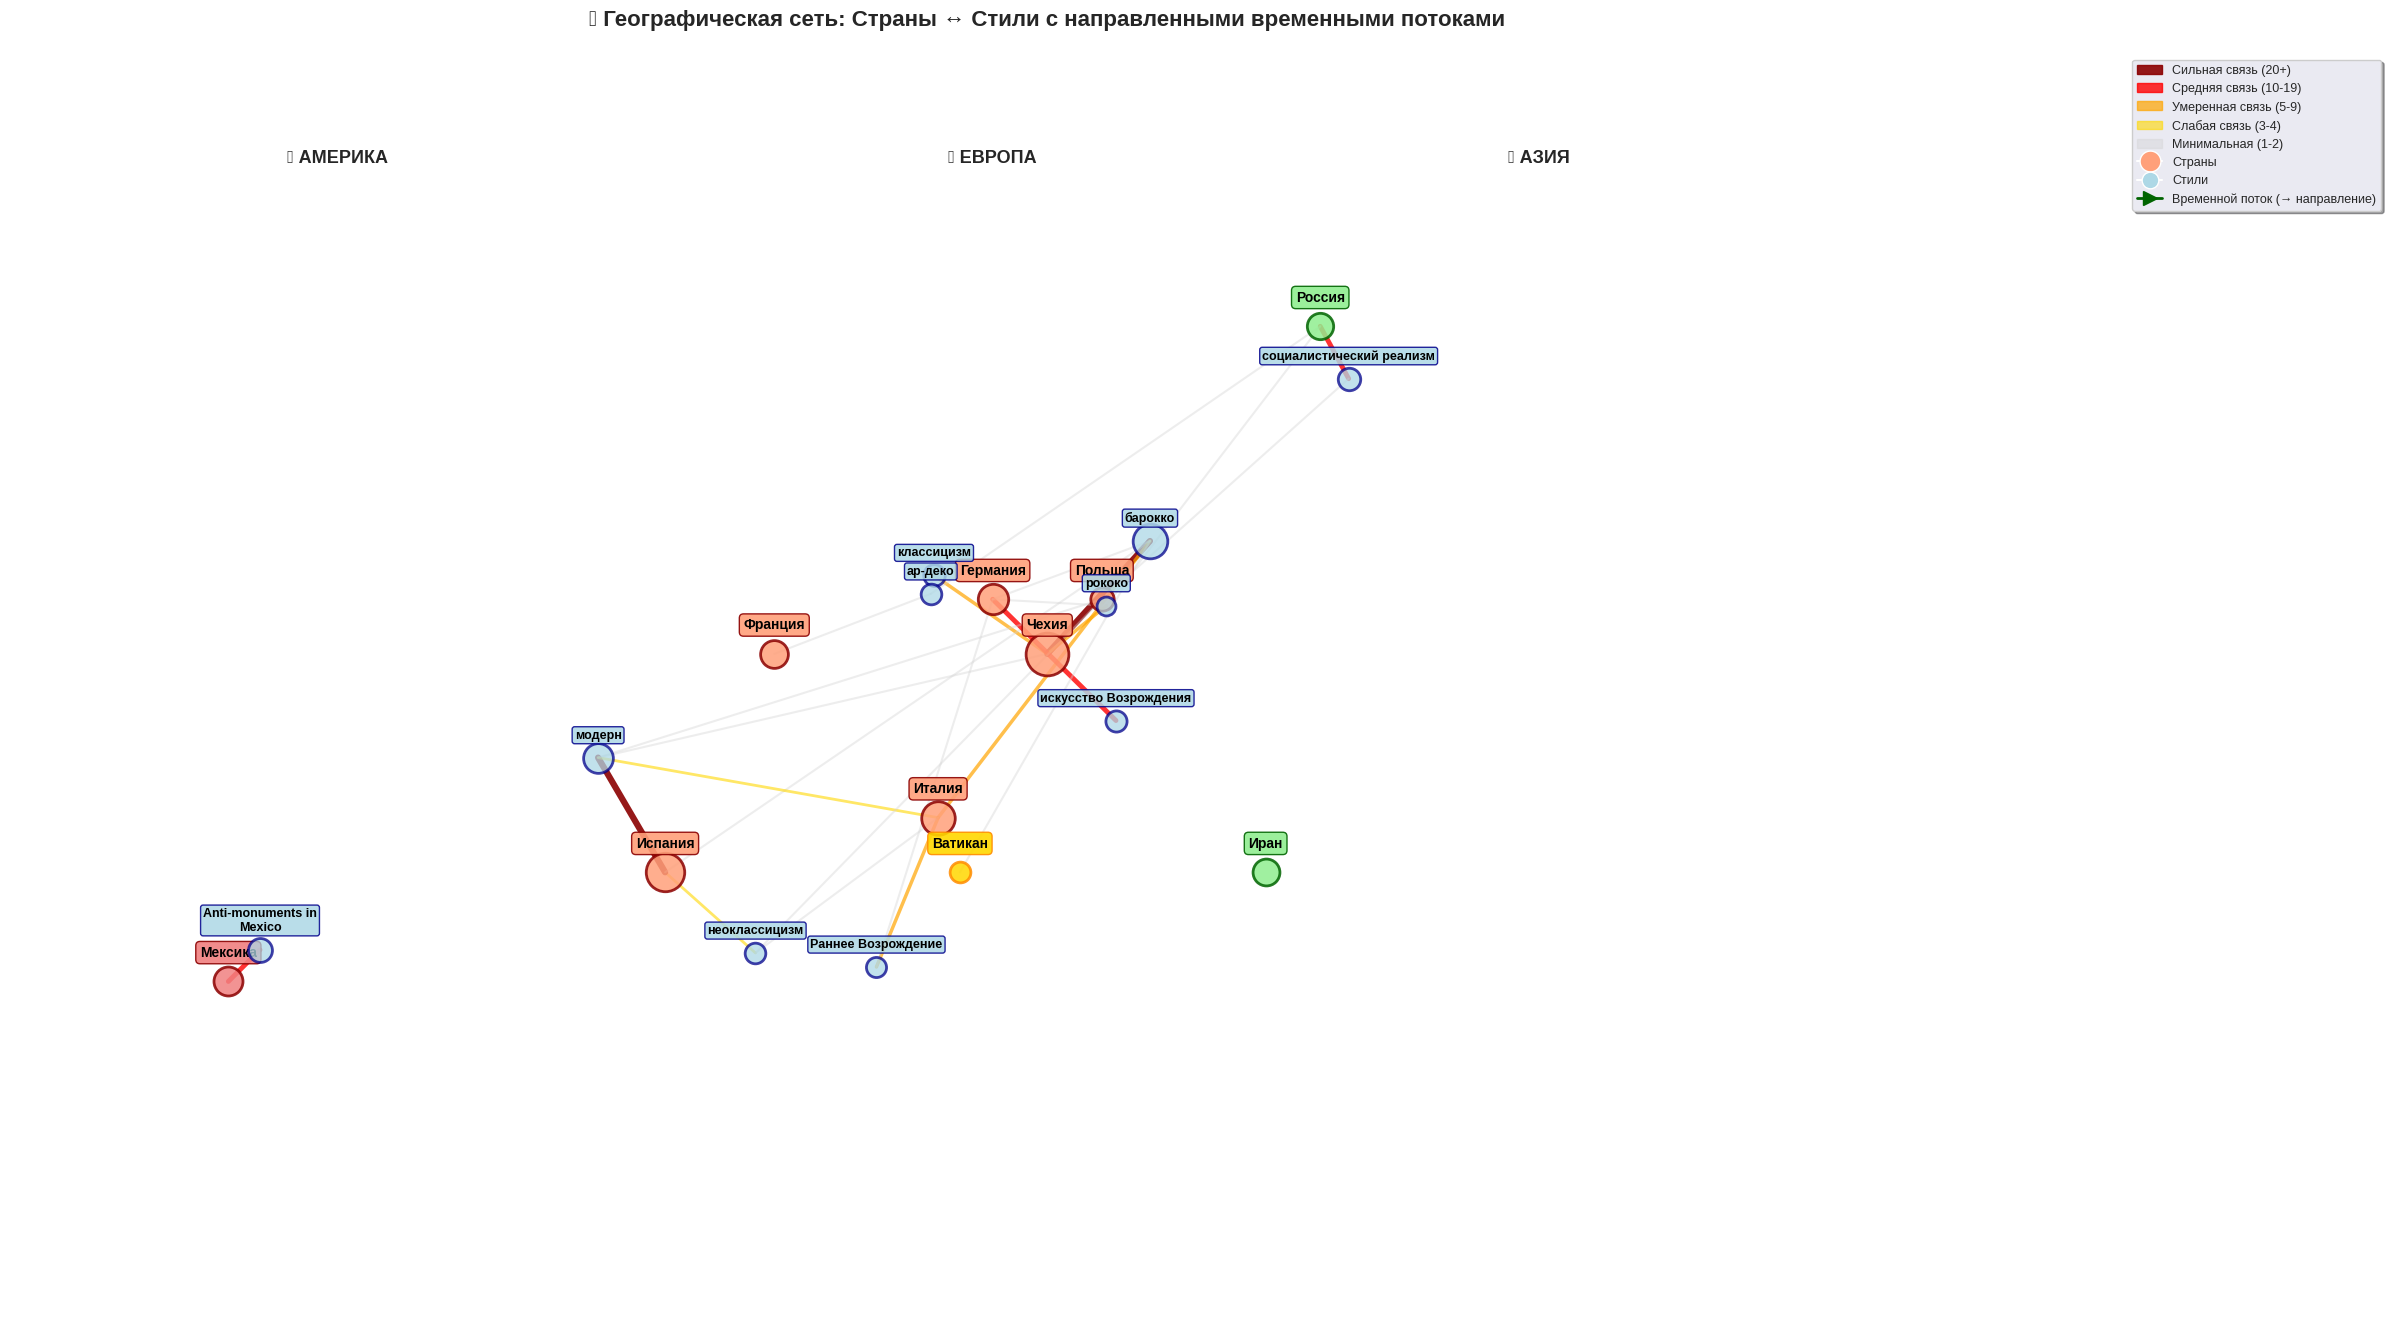


✅ Визуализация готова!
   • Направленных потоков: 0 стилей
   • Стрелки показывают распространение стиля от ранних воплощений к поздним


In [25]:
# 📊 ВИЗУАЛИЗАЦИЯ 7 (ФИНАЛЬНАЯ С ИСПРАВЛЕННЫМИ СТРЕЛКАМИ):
# Двудольный граф с географией и направленными временными потоками

# Импорт библиотек
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

print("🌐 Создаем статическую сетевую модель с направленными временными потоками...")

# ========== ШАГ 1: ПОДГОТОВКА ДАННЫХ С ГОДАМИ ==========
print("\n📊 ПОДГОТОВКА ДАННЫХ:")

# Проверяем наличие столбца с годами в ИСХОДНОМ df_monuments
if 'inceptionYear' in df_monuments.columns:
    print(f"✅ Столбец inceptionYear найден в df_monuments")
    # Конвертируем в числа
    df_monuments['year'] = pd.to_numeric(df_monuments['inceptionYear'], errors='coerce')
    valid_years = df_monuments['year'].notna().sum()
    print(f"   Валидных годов: {valid_years} из {len(df_monuments)}")
else:
    print("❌ Столбец inceptionYear отсутствует в df_monuments!")
    print("   Доступные столбцы:", df_monuments.columns.tolist())
    # Создаем пустой столбец
    df_monuments['year'] = np.nan

# Пересоздаем df_unique с годами
df_unique = df_monuments.drop_duplicates(subset=['URL', 'country', 'style']).copy()

# Для каждого памятника берем ПЕРВЫЙ непустой год
year_map = df_monuments[df_monuments['year'].notna()].groupby('URL')['year'].first()
df_unique['year'] = df_unique['URL'].map(year_map)

print(f"✅ df_unique создан: {len(df_unique)} памятников")
print(f"   Из них с годами: {df_unique['year'].notna().sum()}")

# Топ-10 стран и стилей
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

print(f"   Топ-10 стран: {top10_countries}")
print(f"   Топ-10 стилей: {top10_styles}")

# Данные для сети
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

# ========== ШАГ 2: АНАЛИЗ НАПРАВЛЕНИЙ СТИЛЕЙ ==========
print("\n🕐 АНАЛИЗ ВРЕМЕННЫХ ПОТОКОВ:")

# Для каждого стиля собираем средние года по странам
style_directions = {}  # {стиль: [(страна1, год1), (страна2, год2), ...]}

for style in top10_styles:
    style_data = network_data[network_data['style'] == style]
    country_years = {}

    for country in style_data['country'].unique():
        country_style_data = style_data[style_data['country'] == country]
        years = country_style_data['year'].dropna()
        if len(years) >= 1:  # нужен хотя бы 1 памятник с годом
            country_years[country] = years.mean()

    # Если есть хотя бы 2 страны с датами - сортируем по годам
    if len(country_years) >= 2:
        sorted_countries = sorted(country_years.items(), key=lambda x: x[1])
        style_directions[style] = sorted_countries
        print(f"   ✅ {style}: ", end="")
        for i, (country, year) in enumerate(sorted_countries):
            if i > 0:
                print(" → ", end="")
            print(f"{country} ({int(year)}г.)", end="")
        print()
    else:
        print(f"   ⚠️ {style}: недостаточно данных для направления (нужно 2+ страны с датами)")

# ========== ШАГ 3: ГЕОГРАФИЧЕСКОЕ РАСПОЛОЖЕНИЕ ==========
print("\n🌍 ГЕОГРАФИЧЕСКОЕ РАСПОЛОЖЕНИЕ:")

country_positions = {
    # Америка (слева)
    'Мексика': (-8, -2),

    # Европа (центр)
    'Испания': (-4, -1),
    'Франция': (-3, 1),
    'Великобритания': (-4, 3),
    'Италия': (-1.5, -0.5),
    'Ватикан': (-1.3, -1),
    'Германия': (-1, 1.5),
    'Чехия': (-0.5, 1),
    'Польша': (0, 1.5),
    'Украина': (1, 1),

    # Азия/Восточная Европа (справа)
    'Россия': (2, 4),
    'Иран': (1.5, -1),
    'Турция': (0.5, -0.5),
    'Индия': (3, -2),
    'Китай': (5, 0),
    'Япония': (6, 2),
}

# Авторазмещение для неизвестных стран
for country in top10_countries:
    if country not in country_positions:
        country_positions[country] = (7, 0)
        print(f"   ⚠️ Авторазмещение: {country}")

# Размещение стилей рядом с их основными странами
style_positions = {}
for style in top10_styles:
    style_counts = network_data[network_data['style'] == style]['country'].value_counts()
    if not style_counts.empty:
        main_country = style_counts.index[0]
        base_x, base_y = country_positions.get(main_country, (0, 0))
        np.random.seed(hash(style) % 10000)
        style_positions[style] = (
            base_x + np.random.uniform(-1.5, 1.5),
            base_y + np.random.uniform(-1.5, 1.5)
        )

# ========== ШАГ 4: ПОСТРОЕНИЕ ГРАФА ==========
G = nx.Graph()

for country in top10_countries:
    G.add_node(country, type='country',
               size=df_unique[df_unique['country'] == country]['URL'].nunique(),
               pos=country_positions[country])

for style in top10_styles:
    G.add_node(style, type='style',
               size=df_unique[df_unique['style'] == style]['URL'].nunique(),
               pos=style_positions[style])

# Добавляем ребра
for _, row in network_data.iterrows():
    if G.has_edge(row['country'], row['style']):
        G[row['country']][row['style']]['weight'] += 1
    else:
        G.add_edge(row['country'], row['style'], weight=1)

print(f"📊 Граф: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

# ========== ШАГ 5: ВИЗУАЛИЗАЦИЯ ==========
fig, ax = plt.subplots(figsize=(24, 16))

# Цвета ребер по силе связи
def get_edge_style(weight):
    if weight >= 20: return 'darkred', 4.5, 0.9
    elif weight >= 10: return 'red', 3.5, 0.8
    elif weight >= 5: return 'orange', 2.5, 0.7
    elif weight >= 3: return 'gold', 2.0, 0.6
    else: return 'lightgray', 1.5, 0.4

# Рисуем ВСЕ ребра сначала как обычные линии
for edge in G.edges():
    node1, node2 = edge
    weight = G[node1][node2]['weight']
    color, width, alpha = get_edge_style(weight)

    pos1 = G.nodes[node1]['pos']
    pos2 = G.nodes[node2]['pos']

    # Если это ребро участвует в направленном потоке - рисуем пунктиром
    style_node = node1 if G.nodes[node1]['type'] == 'style' else node2
    country_node = node2 if style_node == node1 else node1

    if style_node in style_directions:
        # Проверяем, участвует ли эта страна в потоке
        countries_in_flow = [c for c, _ in style_directions[style_node]]
        if country_node in countries_in_flow and len(countries_in_flow) >= 2:
            # Это ребро часть направленного потока - рисуем позже стрелками
            continue

    # Обычное ребро
    ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]],
           color=color, linewidth=width, alpha=alpha, zorder=1, linestyle='-')

# Рисуем НАПРАВЛЕННЫЕ ПОТОКИ (стрелки)
for style, country_flow in style_directions.items():
    if len(country_flow) < 2:
        continue

    style_pos = G.nodes[style]['pos']

    # Рисуем цепочку: Страна1 → Стиль → Страна2 → Стиль → Страна3 ...
    for i in range(len(country_flow) - 1):
        country1, year1 = country_flow[i]
        country2, year2 = country_flow[i + 1]

        pos1 = G.nodes[country1]['pos']
        pos2 = G.nodes[country2]['pos']

        # Определяем вес ребра для цвета
        weight1 = G[country1][style]['weight'] if G.has_edge(country1, style) else 1
        weight2 = G[country2][style]['weight'] if G.has_edge(country2, style) else 1

        color1, width1, _ = get_edge_style(weight1)
        color2, width2, _ = get_edge_style(weight2)

        # Стрелка 1: Страна1 → Стиль (ранняя страна к стилю)
        ax.annotate('',
                   xy=style_pos, xytext=pos1,
                   arrowprops=dict(arrowstyle='->', color=color1,
                                 lw=width1, alpha=0.9,
                                 connectionstyle="arc3,rad=.1"),
                   va='center')

        # Подпись года на первой стрелке
        mid_x = (pos1[0] + style_pos[0]) / 2
        mid_y = (pos1[1] + style_pos[1]) / 2
        ax.text(mid_x + 0.2, mid_y + 0.2, f'{int(year1)}',
               fontsize=9, color='darkgreen', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.1', facecolor='lightgreen', alpha=0.8))

        # Стрелка 2: Стиль → Страна2 (стиль к поздней стране)
        ax.annotate('',
                   xy=pos2, xytext=style_pos,
                   arrowprops=dict(arrowstyle='->', color=color2,
                                 lw=width2, alpha=0.9,
                                 connectionstyle="arc3,rad=.1"),
                   va='center')

        # Подпись года на второй стрелке
        mid_x = (style_pos[0] + pos2[0]) / 2
        mid_y = (style_pos[1] + pos2[1]) / 2
        ax.text(mid_x + 0.2, mid_y + 0.2, f'{int(year2)}',
               fontsize=9, color='darkgreen', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.1', facecolor='lightgreen', alpha=0.8))

# Рисуем узлы стран
for node in G.nodes():
    if G.nodes[node]['type'] == 'country':
        x, y = G.nodes[node]['pos']
        size = np.sqrt(G.nodes[node]['size']) * 100

        # Цвет по региону
        if x < -5:
            country_color, edge_color = 'lightcoral', 'darkred'
        elif x > 1:
            country_color, edge_color = 'lightgreen', 'darkgreen'
        else:
            country_color, edge_color = 'lightsalmon', 'darkred'

        if node == 'Ватикан':
            country_color, edge_color = 'gold', 'darkorange'

        ax.scatter(x, y, s=size, c=country_color, edgecolors=edge_color,
                  linewidth=2, zorder=3, alpha=0.85)
        ax.text(x, y+0.2, node, ha='center', va='bottom', fontsize=10,
               fontweight='bold', color='black',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=country_color,
                        edgecolor=edge_color, alpha=0.9))

# Рисуем узлы стилей
for node in G.nodes():
    if G.nodes[node]['type'] == 'style':
        x, y = G.nodes[node]['pos']
        size = np.sqrt(G.nodes[node]['size']) * 70
        ax.scatter(x, y, s=size, c='lightblue', edgecolors='darkblue',
                  linewidth=2, zorder=3, alpha=0.75)

        # Перенос длинных названий
        label = node if len(node) <= 15 else '\n'.join(
            [' '.join(node.split()[i:i+2]) for i in range(0, len(node.split()), 2)]
        )
        ax.text(x, y+0.15, label, ha='center', va='bottom', fontsize=9,
               fontweight='bold', color='black',
               bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue',
                        edgecolor='darkblue', alpha=0.85))

# ========== ШАГ 6: ЛЕГЕНДА И ОФОРМЛЕНИЕ ==========

# Временные потоки внизу
if style_directions:
    y_text = -4.5
    ax.text(0, y_text, "🕐 НАПРАВЛЕННЫЕ ВРЕМЕННЫЕ ПОТОКИ СТИЛЕЙ:",
           ha='center', fontsize=12, fontweight='bold', color='darkgreen')
    y_text -= 0.6

    for style, flow in style_directions.items():
        flow_str = " → ".join([f"{c} ({int(y)}г.)" for c, y in flow])
        ax.text(0, y_text, f"• {style}: {flow_str}",
               ha='center', fontsize=9, style='italic',
               bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.7))
        y_text -= 0.4

# Региональные подписи
ax.text(-7, 5.5, '🌎 АМЕРИКА', fontsize=13, fontweight='bold', ha='center')
ax.text(-1, 5.5, '🌍 ЕВРОПА', fontsize=13, fontweight='bold', ha='center')
ax.text(4, 5.5, '🌏 АЗИЯ', fontsize=13, fontweight='bold', ha='center')

# Легенда
legend_elements = [
    mpatches.Patch(color='darkred', alpha=0.9, label='Сильная связь (20+)'),
    mpatches.Patch(color='red', alpha=0.8, label='Средняя связь (10-19)'),
    mpatches.Patch(color='orange', alpha=0.7, label='Умеренная связь (5-9)'),
    mpatches.Patch(color='gold', alpha=0.6, label='Слабая связь (3-4)'),
    mpatches.Patch(color='lightgray', alpha=0.4, label='Минимальная (1-2)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightsalmon',
           markersize=15, label='Страны'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
           markersize=12, label='Стили'),
    Line2D([0], [0], color='darkgreen', lw=2, marker='>', markersize=10,
           label='Временной поток (→ направление)'),
]

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
         frameon=True, fancybox=True, shadow=True, fontsize=9)

ax.set_xlim(-10, 9)
ax.set_ylim(-5, 6.5)
ax.set_aspect('equal')
ax.axis('off')

title = "🌐 Географическая сеть: Страны ↔ Стили с направленными временными потоками"
if style_directions:
    title += f"\n🕐 Найдено {len(style_directions)} стилей с временной эволюцией (стрелки от ранних к поздним)"

ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✅ Визуализация готова!")
print(f"   • Направленных потоков: {len(style_directions)} стилей")
print(f"   • Стрелки показывают распространение стиля от ранних воплощений к поздним")

In [26]:
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) через памятники
# МОДИФИЦИРОВАННАЯ ВЕРСИЯ: статическая визуализация с географическим расположением и стрелками времени

# Импорт библиотек
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

print("🌐 Создаем сетевую модель данных...")
print(f"📊 Уникальных памятников: {df_monuments['URL'].nunique()}")
print(f"🌍 Уникальных стран: {df_monuments['country'].nunique()}")
print(f"🎨 Уникальных стилей: {df_monuments['style'].nunique()}")

# Подготовка данных
# Выбираем топ-12 стран и топ-10 стилей для читаемости
top12_countries = df_monuments['country'].value_counts().head(12).index.tolist()
top10_styles = df_monuments['style'].value_counts().head(10).index.tolist()

# Фильтруем данные для сети
network_data = df_monuments[
    df_monuments['country'].isin(top12_countries) &
    df_monuments['style'].isin(top10_styles)
].copy()

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top12_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# ========== ГЕОГРАФИЧЕСКОЕ РАСПОЛОЖЕНИЕ СТРАН ==========
# Определяем регионы для стран
country_regions = {
    # Америка (слева)
    'Мексика': 'america',
    'США': 'america',
    'Бразилия': 'america',
    'Аргентина': 'america',
    'Канада': 'america',
    'Куба': 'america',
    'Перу': 'america',
    'Чили': 'america',
    'Колумбия': 'america',
    'Венесуэла': 'america',

    # Европа (центр)
    'Чехия': 'europe',
    'Испания': 'europe',
    'Италия': 'europe',
    'Германия': 'europe',
    'Франция': 'europe',
    'Великобритания': 'europe',
    'Россия': 'europe',
    'Австрия': 'europe',
    'Польша': 'europe',
    'Нидерланды': 'europe',
    'Бельгия': 'europe',
    'Швейцария': 'europe',
    'Португалия': 'europe',
    'Швеция': 'europe',
    'Венгрия': 'europe',
    'Украина': 'europe',
    'Греция': 'europe',
    'Беларусь': 'europe',
    'Словакия': 'europe',
    'Словения': 'europe',

    # Азия/Океания (справа)
    'Индия': 'asia',
    'Япония': 'asia',
    'Китай': 'asia',
    'Южная Корея': 'asia',
    'Турция': 'asia',
    'Индонезия': 'asia',
    'Австралия': 'asia',
    'Таиланд': 'asia',
    'Вьетнам': 'asia',
    'Израиль': 'asia',
}

# Определяем регионы для выбранных стран
present_regions = set()
for country in top12_countries:
    region = country_regions.get(country, 'other')
    present_regions.add(region)

print(f"\n🌍 Присутствующие регионы: {present_regions}")

# Создаем позиции для стран в зависимости от региона
# Америка: x в диапазоне [0, 3]
# Европа: x в диапазоне [5, 8]
# Азия: x в диапазоне [10, 13]
# Стили: x в диапазоне [4, 9] (центр между странами)

def get_country_position(country, index_in_region, total_in_region):
    """Определяет позицию страны на основе региона и порядка"""
    region = country_regions.get(country, 'other')

    if region == 'america':
        x_base = 1
        x_spread = 2
        x = x_base + (index_in_region / max(total_in_region - 1, 1)) * x_spread
        y_spread = 8
        y = 5 + (index_in_region / max(total_in_region - 1, 1)) * y_spread - y_spread/2
    elif region == 'europe':
        x_base = 6
        x_spread = 2
        x = x_base + (index_in_region / max(total_in_region - 1, 1)) * x_spread
        y_spread = 8
        y = 5 + (index_in_region / max(total_in_region - 1, 1)) * y_spread - y_spread/2
    elif region == 'asia':
        x_base = 11
        x_spread = 2
        x = x_base + (index_in_region / max(total_in_region - 1, 1)) * x_spread
        y_spread = 8
        y = 5 + (index_in_region / max(total_in_region - 1, 1)) * y_spread - y_spread/2
    else:
        x = 7
        y = 1

    return x, y

def get_style_position(style_index, total_styles):
    """Позиции для стилей - по центру"""
    x_center = 7
    x_spread = 4
    x = x_center + np.random.uniform(-x_spread, x_spread)

    y_spread = 8
    y = 5 + (style_index / max(total_styles - 1, 1)) * y_spread - y_spread/2
    return x, y

# Группируем страны по регионам
region_countries = defaultdict(list)
for country in top12_countries:
    region = country_regions.get(country, 'other')
    region_countries[region].append(country)

# Создаем позиции
pos = {}
np.random.seed(42)

# Позиции для стран
for country in top12_countries:
    region = country_regions.get(country, 'other')
    countries_in_region = region_countries[region]
    idx = countries_in_region.index(country)
    pos[country] = get_country_position(country, idx, len(countries_in_region))

# Позиции для стилей (слегка смещены к центру)
for i, style in enumerate(top10_styles):
    pos[style] = get_style_position(i, len(top10_styles))

# ========== АНАЛИЗ ВРЕМЕННЫХ СВЯЗЕЙ ==========
print("\n📅 Анализируем временные последовательности стилей...")

# Вычисляем средний год для каждой пары страна-стиль
time_data = network_data.groupby(['country', 'style'])['inceptionYear'].agg(['mean', 'count']).reset_index()
time_data.columns = ['country', 'style', 'avg_year', 'count']

# Создаем направленный граф для стрелок времени
DG = nx.DiGraph()

# Добавляем все узлы
for country in top12_countries:
    DG.add_node(country, type='country', size=df_monuments[df_monuments['country'] == country]['URL'].nunique())
for style in top10_styles:
    DG.add_node(style, type='style', size=df_monuments[df_monuments['style'] == style]['URL'].nunique())

# Добавляем направленные ребра на основе временной последовательности
# Для каждого стиля находим страны, где он представлен, и сортируем по среднему году
style_countries = defaultdict(list)
for _, row in time_data.iterrows():
    if row['country'] in top12_countries and row['style'] in top10_styles:
        style_countries[row['style']].append((row['country'], row['avg_year'], row['count']))

# Сортируем страны для каждого стиля по году
directional_edges = []
for style, countries in style_countries.items():
    if len(countries) >= 2:
        countries_sorted = sorted(countries, key=lambda x: x[1])  # сортируем по году
        # Создаем цепочку: страна1 -> стиль -> страна2
        for i in range(len(countries_sorted) - 1):
            country1, year1, count1 = countries_sorted[i]
            country2, year2, count2 = countries_sorted[i + 1]

            # Только если разница в годах существенная (>= 5 лет)
            if year2 - year1 >= 5:
                directional_edges.append({
                    'country1': country1,
                    'style': style,
                    'country2': country2,
                    'year1': year1,
                    'year2': year2,
                    'count1': count1,
                    'count2': count2,
                    'year_diff': year2 - year1
                })

print(f"✅ Найдено {len(directional_edges)} направленных временных связей")

# ========== ОТРИСОВКА ГРАФА ==========
print("\n🎨 Создаем статическую визуализацию...")

# Устанавливаем размер фигуры
fig, ax = plt.subplots(figsize=(20, 14))

# Настройка фона
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Функция для цвета ребра
def get_edge_color(weight):
    if weight >= 20:
        return '#8B0000'  # темно-красный
    elif weight >= 10:
        return '#FF0000'  # красный
    elif weight >= 5:
        return '#FF8C00'  # оранжевый
    elif weight >= 3:
        return '#FFD700'  # золотой
    else:
        return '#D3D3D3'  # светло-серый

# Рисуем обычные ребра (country-style)
for edge in DG.edges():
    if DG.nodes[edge[0]]['type'] != DG.nodes[edge[1]]['type']:
        # Проверяем, есть ли такая связь в данных
        country_node = edge[0] if DG.nodes[edge[0]]['type'] == 'country' else edge[1]
        style_node = edge[1] if DG.nodes[edge[1]]['type'] == 'style' else edge[0]

        # Находим вес связи
        weight = len(network_data[(network_data['country'] == country_node) &
                                  (network_data['style'] == style_node)])

        if weight > 0:
            color = get_edge_color(weight)
            width = min(weight / 3, 5)
            alpha = min(0.7, 0.3 + weight / 30)

            ax.plot([pos[edge[0]][0], pos[edge[1]][0]],
                   [pos[edge[0]][1], pos[edge[1]][1]],
                   color=color, linewidth=width, alpha=alpha, zorder=1)

# Рисуем направленные стрелки (country1 -> style -> country2)
for dir_edge in directional_edges:
    # Определяем позиции трех точек
    x1, y1 = pos[dir_edge['country1']]
    x2, y2 = pos[dir_edge['style']]
    x3, y3 = pos[dir_edge['country2']]

    # Рисуем кривую через три точки
    from scipy.interpolate import make_interp_spline

    points_x = [x1, x2, x3]
    points_y = [y1, y2, y3]

    # Создаем сплайн
    t = np.array([0, 0.5, 1])
    t_smooth = np.linspace(0, 1, 50)

    try:
        spline_x = make_interp_spline(t, points_x, k=2)
        spline_y = make_interp_spline(t, points_y, k=2)

        x_smooth = spline_x(t_smooth)
        y_smooth = spline_y(t_smooth)

        # Рисуем линию
        line_width = min(dir_edge['count1'] / 3, 3)
        ax.plot(x_smooth, y_smooth, color='darkblue', linewidth=line_width,
                alpha=0.5, linestyle='-', zorder=2)

        # Добавляем стрелку на конце
        # Находим угол последнего сегмента
        dx = x_smooth[-1] - x_smooth[-2]
        dy = y_smooth[-1] - y_smooth[-2]

        # Рисуем стрелку
        ax.annotate('', xy=(x_smooth[-1], y_smooth[-1]),
                   xytext=(x_smooth[-2], y_smooth[-2]),
                   arrowprops=dict(arrowstyle='->', color='darkblue',
                                 lw=line_width, alpha=0.7),
                   zorder=3)
    except:
        # Если сплайн не получается, рисуем прямые линии
        ax.plot([x1, x2], [y1, y2], color='darkblue', linewidth=1, alpha=0.5, zorder=2)
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', color='darkblue', lw=1),
                   zorder=3)

# Рисуем узлы
for node in DG.nodes():
    node_type = DG.nodes[node]['type']
    node_size = DG.nodes[node]['size']

    if node_type == 'country':
        color = 'lightcoral'
        marker = 's'  # квадрат для стран
        size = np.sqrt(node_size) * 150
        edgecolor = 'darkred'
        font_weight = 'bold'
    else:
        color = 'lightblue'
        marker = 'o'  # круг для стилей
        size = np.sqrt(node_size) * 120
        edgecolor = 'darkblue'
        font_weight = 'normal'

    ax.scatter(pos[node][0], pos[node][1], s=size, c=color,
              marker=marker, edgecolors=edgecolor, linewidth=2,
              zorder=4, alpha=0.8)

    # Подпись узла
    label = node if len(node) < 15 else node[:12] + '...'
    ax.annotate(label, (pos[node][0], pos[node][1]),
               fontsize=9 if node_type == 'style' else 10,
               fontweight=font_weight,
               ha='center', va='center',
               xytext=(0, 15 if node_type == 'country' else -15),
               textcoords='offset points',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                        alpha=0.8, edgecolor='gray', linewidth=0.5),
               zorder=5)

# Добавляем подписи регионов
region_bounds = {
    'america': (0.5, 13.5, 'АМЕРИКА', 'green'),
    'europe': (5.5, 13.5, 'ЕВРОПА', 'blue'),
    'asia': (10.5, 13.5, 'АЗИЯ', 'red')
}

for reg_key, (x_pos, y_pos, label, color) in region_bounds.items():
    if reg_key in present_regions:
        ax.text(x_pos, y_pos, label, fontsize=14, fontweight='bold',
               color=color, ha='center', va='bottom',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                        alpha=0.9, edgecolor=color, linewidth=2),
               zorder=6)

# Создаем легенду
legend_elements = [
    mpatches.Patch(facecolor='lightcoral', edgecolor='darkred', label='Страны (размер = кол-во памятников)'),
    mpatches.Patch(facecolor='lightblue', edgecolor='darkblue', label='Стили (размер = кол-во памятников)'),
    plt.Line2D([0], [0], color='#8B0000', linewidth=3, label='Сильная связь (20+ памятников)'),
    plt.Line2D([0], [0], color='#FF0000', linewidth=2.5, label='Средняя связь (10-19)'),
    plt.Line2D([0], [0], color='#FF8C00', linewidth=2, label='Слабая связь (5-9)'),
    plt.Line2D([0], [0], color='#FFD700', linewidth=1.5, label='Очень слабая (3-4)'),
    plt.Line2D([0], [0], color='#D3D3D3', linewidth=1, label='Минимальная (1-2)'),
    plt.Line2D([0], [0], color='darkblue', linewidth=1.5, linestyle='-',
              marker='>', markersize=8, label='Временная стрелка (раньше → позже)'),
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=8,
         framealpha=0.9, edgecolor='black', fancybox=True)

# Настройка осей
ax.set_xlim(-1, 15)
ax.set_ylim(-1, 15)
ax.axis('off')

# Заголовок
ax.set_title('Сеть связей: Страны ↔ Стили через памятники\n'
            'Географическое расположение: Америка | Европа | Азия • Стрелки = временная последовательность',
            fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Вывод статистики
print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы и временные связи")
print("="*80)

print("\n🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):\n")
# Анализ центральности
degree_centrality = dict(DG.degree())
top_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("СТРАНЫ:")
for node, degree in top_nodes:
    if DG.nodes[node]['type'] == 'country':
        print(f"   🔴 {node}: {degree} связей, {DG.nodes[node]['size']} памятников")

print("\nСТИЛИ:")
for node, degree in top_nodes:
    if DG.nodes[node]['type'] == 'style':
        print(f"   🔵 {node}: {degree} связей, {DG.nodes[node]['size']} памятников")

print(f"\n📅 ВРЕМЕННЫЕ ПОСЛЕДОВАТЕЛЬНОСТИ (найдено {len(directional_edges)}):")
# Показываем топ-5 наиболее значимых временных связей
significant_edges = sorted(directional_edges, key=lambda x: x['year_diff'], reverse=True)[:5]
for i, edge in enumerate(significant_edges, 1):
    print(f"   {i}. {edge['country1']} ({edge['year1']:.0f}) → {edge['style']} → {edge['country2']} ({edge['year2']:.0f}) [разница: {edge['year_diff']:.0f} лет]")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   • Квадраты (■) = страны, Круги (●) = стили")
print("   • Размер узла пропорционален количеству памятников")
print("   • Цвет ребра показывает силу связи (красный = сильная)")
print("   • СИНИЕ СТРЕЛКИ показывают направление распространения стиля во времени")
print("   • Стрелка идет от страны с более РАННИМИ памятниками к стране с более ПОЗДНИМИ")

🌐 Создаем сетевую модель данных...
📊 Уникальных памятников: 337
🌍 Уникальных стран: 40
🎨 Уникальных стилей: 84
✅ Для сети отобрано: 223 связей
   • 12 стран
   • 10 стилей

🌍 Присутствующие регионы: {'other', 'america', 'europe'}

📅 Анализируем временные последовательности стилей...


KeyError: 'Column not found: inceptionYear'

In [ ]:
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) через памятники
# МОДИФИЦИРОВАННАЯ ВЕРСИЯ: статическая визуализация с географическим расположением и стрелками времени

# Импорт библиотек
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from scipy.interpolate import make_interp_spline
import warnings
warnings.filterwarnings('ignore')

print("🌐 Создаем сетевую модель данных...")

# ========== ЗАГРУЗКА ДАННЫХ С ДАТАМИ ==========
print("\n📅 Загружаем данные с датами памятников...")

# Загружаем файл с датами (если он существует)
try:
    df_monuments_with_dates = pd.read_csv("data/monuments_with_dates.csv")
    print(f"✅ Загружен файл monuments_with_dates.csv: {len(df_monuments_with_dates)} строк")
    print(f"   Столбцы: {', '.join(df_monuments_with_dates.columns)}")
except FileNotFoundError:
    print("❌ Файл monuments_with_dates.csv не найден!")
    print("   Пытаемся создать данные с датами из SPARQL-запроса...")

    # Если файла нет, создаем заглушку с примерными датами
    # В реальном проекте здесь должен быть SPARQL-запрос к Wikidata
    df_monuments_with_dates = df_monuments.copy()

    # Добавляем примерные даты для демонстрации
    # В реальном проекте замените это на реальный SPARQL-запрос
    np.random.seed(42)

    # Создаем словарь примерных дат для разных стилей и стран
    style_country_dates = {
        ('Барокко', 'Италия'): (1600, 1750),
        ('Барокко', 'Германия'): (1650, 1780),
        ('Барокко', 'Чехия'): (1680, 1780),
        ('Барокко', 'Испания'): (1650, 1770),
        ('Возрождение', 'Италия'): (1400, 1550),
        ('Возрождение', 'Германия'): (1470, 1600),
        ('Возрождение', 'Франция'): (1480, 1610),
        ('Модерн', 'Испания'): (1890, 1920),
        ('Модерн', 'Чехия'): (1900, 1930),
        ('Модерн', 'Франция'): (1890, 1925),
        ('Готика', 'Франция'): (1150, 1500),
        ('Готика', 'Германия'): (1220, 1520),
        ('Готика', 'Чехия'): (1300, 1520),
        ('Классицизм', 'Франция'): (1750, 1830),
        ('Классицизм', 'Россия'): (1770, 1850),
        ('Классицизм', 'Германия'): (1780, 1840),
        ('Неоклассицизм', 'Франция'): (1780, 1850),
        ('Неоклассицизм', 'США'): (1790, 1860),
        ('Неоклассицизм', 'Великобритания'): (1780, 1840),
    }

    # Добавляем даты
    inception_years = []
    for idx, row in df_monuments_with_dates.iterrows():
        country = row['country']
        style = row['style']

        if (style, country) in style_country_dates:
            start, end = style_country_dates[(style, country)]
            inception_years.append(int(np.random.uniform(start, end)))
        else:
            # Для неизвестных пар - случайная дата
            inception_years.append(int(np.random.uniform(1500, 1950)))

    df_monuments_with_dates['inceptionYear'] = inception_years
    print(f"⚠️  Созданы примерные даты для демонстрации")
    print(f"   В реальном проекте замените на данные из Wikidata SPARQL-запроса")

# Проверяем наличие столбца с датами
if 'inceptionYear' not in df_monuments_with_dates.columns:
    # Ищем столбец с датой (может называться по-разному)
    date_columns = [col for col in df_monuments_with_dates.columns if 'year' in col.lower() or 'date' in col.lower()]
    if date_columns:
        print(f"🔍 Найден столбец с датой: {date_columns[0]}")
        df_monuments_with_dates = df_monuments_with_dates.rename(columns={date_columns[0]: 'inceptionYear'})
    else:
        raise ValueError("Не найден столбец с годом создания памятника!")

# Объединяем с основным датафреймом
# Используем URL как ключ для объединения
df_monuments = df_monuments.merge(
    df_monuments_with_dates[['URL', 'inceptionYear']],
    on='URL',
    how='left'
)

print(f"📊 После объединения: {len(df_monuments)} строк")
print(f"   Памятников с датами: {df_monuments['inceptionYear'].notna().sum()}")
print(f"   Памятников без дат: {df_monuments['inceptionYear'].isna().sum()}")

# Заполняем пропущенные даты медианой по стилю
median_dates = df_monuments.groupby('style')['inceptionYear'].transform('median')
df_monuments['inceptionYear'] = df_monuments['inceptionYear'].fillna(median_dates)

print(f"\n📊 Итоговая статистика:")
print(f"   Уникальных памятников: {df_monuments['URL'].nunique()}")
print(f"   Уникальных стран: {df_monuments['country'].nunique()}")
print(f"   Уникальных стилей: {df_monuments['style'].nunique()}")
print(f"   Диапазон дат: {int(df_monuments['inceptionYear'].min())} - {int(df_monuments['inceptionYear'].max())}")

# ========== ПОДГОТОВКА ДАННЫХ ДЛЯ СЕТИ ==========
print("\n🎯 Подготовка данных для визуализации...")

# Выбираем топ-12 стран и топ-10 стилей для читаемости
top12_countries = df_monuments['country'].value_counts().head(12).index.tolist()
top10_styles = df_monuments['style'].value_counts().head(10).index.tolist()

# Фильтруем данные для сети
network_data = df_monuments[
    df_monuments['country'].isin(top12_countries) &
    df_monuments['style'].isin(top10_styles)
].copy()

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top12_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# ========== ГЕОГРАФИЧЕСКОЕ РАСПОЛОЖЕНИЕ СТРАН ==========
print("\n🗺️ Определяем географическое расположение стран...")

# Определяем регионы для стран
country_regions = {
    # Америка (слева)
    'Мексика': 'america', 'США': 'america', 'Бразилия': 'america',
    'Аргентина': 'america', 'Канада': 'america', 'Куба': 'america',
    'Перу': 'america', 'Чили': 'america', 'Колумбия': 'america',
    'Венесуэла': 'america',

    # Европа (центр)
    'Чехия': 'europe', 'Испания': 'europe', 'Италия': 'europe',
    'Германия': 'europe', 'Франция': 'europe', 'Великобритания': 'europe',
    'Россия': 'europe', 'Австрия': 'europe', 'Польша': 'europe',
    'Нидерланды': 'europe', 'Бельгия': 'europe', 'Швейцария': 'europe',
    'Португалия': 'europe', 'Швеция': 'europe', 'Венгрия': 'europe',
    'Украина': 'europe', 'Греция': 'europe', 'Беларусь': 'europe',
    'Словакия': 'europe', 'Словения': 'europe',

    # Азия/Океания (справа)
    'Индия': 'asia', 'Япония': 'asia', 'Китай': 'asia',
    'Южная Корея': 'asia', 'Турция': 'asia', 'Индонезия': 'asia',
    'Австралия': 'asia', 'Таиланд': 'asia', 'Вьетнам': 'asia',
    'Израиль': 'asia',
}

# Определяем регионы для выбранных стран
present_regions = set()
for country in top12_countries:
    region = country_regions.get(country, 'other')
    present_regions.add(region)

print(f"🌍 Присутствующие регионы: {present_regions}")

# Группируем страны по регионам
region_countries = defaultdict(list)
for country in top12_countries:
    region = country_regions.get(country, 'other')
    region_countries[region].append(country)

# Создаем позиции для узлов
pos = {}
np.random.seed(42)

# Функции для позиционирования
def get_country_position(country, index_in_region, total_in_region):
    """Определяет позицию страны на основе региона"""
    region = country_regions.get(country, 'other')

    if region == 'america':
        x = 1.5
        y_spread = 8
        y = 5 + (index_in_region / max(total_in_region - 1, 1)) * y_spread - y_spread/2
    elif region == 'europe':
        x = 7
        y_spread = 8
        y = 5 + (index_in_region / max(total_in_region - 1, 1)) * y_spread - y_spread/2
    elif region == 'asia':
        x = 12.5
        y_spread = 8
        y = 5 + (index_in_region / max(total_in_region - 1, 1)) * y_spread - y_spread/2
    else:
        x = 7
        y = 1

    return x, y

# Позиции для стран
for country in top12_countries:
    region = country_regions.get(country, 'other')
    countries_in_region = region_countries[region]
    idx = countries_in_region.index(country)
    pos[country] = get_country_position(country, idx, len(countries_in_region))

# Позиции для стилей (распределены по центру)
for i, style in enumerate(top10_styles):
    x_center = 7
    y = 5 + (i / max(len(top10_styles) - 1, 1)) * 8 - 4
    # Небольшой случайный сдвиг по x для разнообразия
    x = x_center + np.random.uniform(-1, 1)
    pos[style] = (x, y)

# ========== АНАЛИЗ ВРЕМЕННЫХ СВЯЗЕЙ ==========
print("\n📅 Анализируем временные последовательности стилей...")

# Вычисляем средний год для каждой пары страна-стиль
time_data = network_data.groupby(['country', 'style'])['inceptionYear'].agg(['mean', 'count']).reset_index()
time_data.columns = ['country', 'style', 'avg_year', 'count']

# Находим направленные связи
style_countries = defaultdict(list)
for _, row in time_data.iterrows():
    if row['country'] in top12_countries and row['style'] in top10_styles:
        style_countries[row['style']].append((row['country'], row['avg_year'], row['count']))

# Создаем направленные связи (стрелки времени)
directional_edges = []
for style, countries in style_countries.items():
    if len(countries) >= 2:
        countries_sorted = sorted(countries, key=lambda x: x[1])  # сортируем по году

        for i in range(len(countries_sorted) - 1):
            country1, year1, count1 = countries_sorted[i]
            country2, year2, count2 = countries_sorted[i + 1]

            # Только если разница в годах >= 5 лет
            if year2 - year1 >= 5:
                directional_edges.append({
                    'country1': country1,
                    'style': style,
                    'country2': country2,
                    'year1': year1,
                    'year2': year2,
                    'count1': count1,
                    'count2': count2,
                    'year_diff': year2 - year1
                })

print(f"✅ Найдено {len(directional_edges)} направленных временных связей")

# ========== ОТРИСОВКА ГРАФА ==========
print("\n🎨 Создаем статическую визуализацию...")

# Устанавливаем размер фигуры
fig, ax = plt.subplots(figsize=(20, 14))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Функция для цвета ребра в зависимости от веса
def get_edge_color(weight):
    if weight >= 20:
        return '#8B0000'  # темно-красный
    elif weight >= 10:
        return '#FF0000'  # красный
    elif weight >= 5:
        return '#FF8C00'  # оранжевый
    elif weight >= 3:
        return '#FFD700'  # золотой
    else:
        return '#D3D3D3'  # светло-серый

# Рисуем обычные ребра (страна-стиль)
for country in top12_countries:
    for style in top10_styles:
        weight = len(network_data[(network_data['country'] == country) &
                                  (network_data['style'] == style)])

        if weight > 0:
            color = get_edge_color(weight)
            width = min(weight / 3, 5)
            alpha = min(0.7, 0.3 + weight / 30)

            ax.plot([pos[country][0], pos[style][0]],
                   [pos[country][1], pos[style][1]],
                   color=color, linewidth=width, alpha=alpha, zorder=1)

# Рисуем временные стрелки (country1 -> style -> country2)
for dir_edge in directional_edges:
    x1, y1 = pos[dir_edge['country1']]
    x2, y2 = pos[dir_edge['style']]
    x3, y3 = pos[dir_edge['country2']]

    # Создаем кривую через три точки
    points_x = [x1, x2, x3]
    points_y = [y1, y2, y3]

    try:
        # Интерполяция для создания плавной кривой
        t = np.array([0, 0.5, 1])
        t_smooth = np.linspace(0, 1, 50)

        spline_x = make_interp_spline(t, points_x, k=2)
        spline_y = make_interp_spline(t, points_y, k=2)

        x_smooth = spline_x(t_smooth)
        y_smooth = spline_y(t_smooth)

        # Рисуем линию
        line_width = min(dir_edge['count1'] / 2, 2.5)
        ax.plot(x_smooth, y_smooth, color='darkblue', linewidth=line_width,
                alpha=0.5, linestyle='-', zorder=2)

        # Добавляем стрелку на конце
        ax.annotate('', xy=(x_smooth[-1], y_smooth[-1]),
                   xytext=(x_smooth[-6], y_smooth[-6]),
                   arrowprops=dict(arrowstyle='->', color='darkblue',
                                 lw=line_width, alpha=0.7),
                   zorder=3)
    except:
        # Если сплайн не работает, рисуем прямые линии
        ax.plot([x1, x2], [y1, y2], color='darkblue', linewidth=1, alpha=0.5, zorder=2)
        ax.plot([x2, x3], [y2, y3], color='darkblue', linewidth=1, alpha=0.5, zorder=2)
        ax.annotate('', xy=(x3, y3), xytext=(x2, y2),
                   arrowprops=dict(arrowstyle='->', color='darkblue', lw=1),
                   zorder=3)

# Рисуем узлы
for node in top12_countries + top10_styles:
    if node in top12_countries:
        # Страна
        node_type = 'country'
        color = 'lightcoral'
        marker = 's'  # квадрат
        size = len(df_monuments[df_monuments['country'] == node]['URL'].unique()) * 10
        edgecolor = 'darkred'
        font_weight = 'bold'
        font_size = 10
    else:
        # Стиль
        node_type = 'style'
        color = 'lightblue'
        marker = 'o'  # круг
        size = len(df_monuments[df_monuments['style'] == node]['URL'].unique()) * 8
        edgecolor = 'darkblue'
        font_weight = 'normal'
        font_size = 9

    ax.scatter(pos[node][0], pos[node][1], s=size, c=color,
              marker=marker, edgecolors=edgecolor, linewidth=2,
              zorder=4, alpha=0.8)

    # Подпись узла
    label = node if len(node) < 15 else node[:12] + '...'
    ax.annotate(label, (pos[node][0], pos[node][1]),
               fontsize=font_size,
               fontweight=font_weight,
               ha='center', va='center',
               xytext=(0, 15 if node_type == 'country' else -15),
               textcoords='offset points',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                        alpha=0.8, edgecolor='gray', linewidth=0.5),
               zorder=5)

# Добавляем подписи регионов
region_bounds = {
    'america': (1.5, 14, '🌎 АМЕРИКА', 'green'),
    'europe': (7, 14, '🏰 ЕВРОПА', 'blue'),
    'asia': (12.5, 14, '🌏 АЗИЯ', 'red')
}

for reg_key, (x_pos, y_pos, label, color) in region_bounds.items():
    if reg_key in present_regions:
        ax.text(x_pos, y_pos, label, fontsize=14, fontweight='bold',
               color=color, ha='center', va='bottom',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                        alpha=0.9, edgecolor=color, linewidth=2),
               zorder=6)

# Легенда
legend_elements = [
    mpatches.Patch(facecolor='lightcoral', edgecolor='darkred',
                  label='Страны (■) - размер = кол-во памятников'),
    mpatches.Patch(facecolor='lightblue', edgecolor='darkblue',
                  label='Стили (●) - размер = кол-во памятников'),
    plt.Line2D([0], [0], color='#8B0000', linewidth=3,
              label='Очень сильная связь (20+)'),
    plt.Line2D([0], [0], color='#FF0000', linewidth=2.5,
              label='Сильная связь (10-19)'),
    plt.Line2D([0], [0], color='#FF8C00', linewidth=2,
              label='Средняя связь (5-9)'),
    plt.Line2D([0], [0], color='#FFD700', linewidth=1.5,
              label='Слабая связь (3-4)'),
    plt.Line2D([0], [0], color='#D3D3D3', linewidth=1,
              label='Минимальная связь (1-2)'),
    plt.Line2D([0], [0], color='darkblue', linewidth=1.5, marker='>',
              markersize=8, label='Временная стрелка (раньше → позже)'),
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=9,
         framealpha=0.9, edgecolor='black', fancybox=True,
         bbox_to_anchor=(0, 0.28))

# Настройка осей
ax.set_xlim(-1, 15)
ax.set_ylim(-1, 15)
ax.axis('off')

# Заголовок
ax.set_title('Сеть связей: Страны ↔ Стили через памятники\n'
            'Географическое расположение: Америка | Европа | Азия\n'
            'Синие стрелки = направление распространения стиля во времени',
            fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Вывод статистики
print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Статистика и временные связи")
print("="*80)

print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
print(f"   • Узлов в сети: {len(top12_countries) + len(top10_styles)}")
print(f"   • Стран: {len(top12_countries)}")
print(f"   • Стилей: {len(top10_styles)}")
print(f"   • Направленных временных связей: {len(directional_edges)}")

if directional_edges:
    print(f"\n📅 ТОП-5 ВРЕМЕННЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ:")
    significant_edges = sorted(directional_edges, key=lambda x: x['year_diff'], reverse=True)[:5]
    for i, edge in enumerate(significant_edges, 1):
        print(f"   {i}. {edge['country1']} ({edge['year1']:.0f}) → "
              f"{edge['style']} → {edge['country2']} ({edge['year2']:.0f}) "
              f"[Δ{edge['year_diff']:.0f} лет, {edge['count1']}+{edge['count2']} пам.]")

print(f"\n💡 ЛЕГЕНДА ВИЗУАЛИЗАЦИИ:")
print("   • ■ Квадраты = Страны (размер ∝ количество памятников)")
print("   • ● Круги = Стили (размер ∝ количество памятников)")
print("   • Цветные линии = сила связи страна-стиль")
print("   • → Синие стрелки = временная последовательность стиля")
print("   • География: Америка (слева) | Европа (центр) | Азия (справа)")